# 02 · Forecasting realized variance

Part 2 of 5. The question here: **can a statistical model forecast the next 21 days of realized variance better than the VIX itself?**

If it can, the gap from notebook 01 could be predicted, and a seller could avoid the months when the premium is likely to be negative. If it cannot, the VIX is already the best available forecast and the only edge left is the premium itself.

Four forecasts are compared:

| model | idea |
|---|---|
| **VIX²** | the market's own forecast, used as is |
| **HAR** (Corsi, 2009) | regression of future variance on yesterday's, last week's and last month's realized variance |
| **HAR-X** | HAR plus the VIX² as an extra regressor |
| **GARCH(1,1)-t** | variance that reacts to recent shocks and decays back to a long-run level, with Student-t errors |

All models are estimated **walk-forward**: each forecast uses only data that was available on the day, and the parameters are refit every 21 days (HAR) or 63 days (GARCH). A unit test in the repository checks that changing future returns leaves past forecasts untouched.

Losses are computed on variance, over January 2020 to September 2026. The models are trained on data from 1990.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from vrp.data import load_market_data
from vrp.volatility import forward_realized_variance, log_returns

END = "2026-09-25"                   # last complete session used for the published results
EVAL_START = pd.Timestamp("2020-01-01")

data = load_market_data("yahoo", "1990-01-01", END)
spx, vix = data["spx"], data["vix"]
returns = log_returns(spx)
realized_var = forward_realized_variance(returns)   # RV(t, t+21), annualised
realized_vol = np.sqrt(realized_var)
implied_var = (vix / 100) ** 2
print(f"{len(data):,} daily observations, {spx.index[0].date()} to {spx.index[-1].date()}")

9,251 daily observations, 1990-01-02 to 2026-09-25


In [2]:
from vrp.volatility import evaluate_forecasts, walk_forward_garch, walk_forward_har

har, _ = walk_forward_har(returns)
har_x, har_x_coefs = walk_forward_har(returns, implied_variance=implied_var)
garch = walk_forward_garch(returns)          # about 20 seconds

forecasts = {
    "Implied (VIX^2)": implied_var.reindex(returns.index),
    "HAR": har,
    "HAR-X (HAR + VIX)": har_x,
    "GARCH(1,1)-t": garch,
}
window = {name: f.loc[EVAL_START:] for name, f in forecasts.items()}
evaluation = evaluate_forecasts(window, realized_var.loc[EVAL_START:])
evaluation.index.name = "model"
table = evaluation.copy()
table["mse_variance"] = 1000 * table["mse_variance"]
table = table.rename(columns={"mse_variance": "mse_variance (x1e-3)"})
table.round(3)

,rmse_vol_pts,mse_variance (x1e-3),qlike,bias_vol_pts,mz_intercept,mz_slope,mz_r2
model,,,,,,,
Implied (VIX^2),10.212,7.549,0.444,3.828,0.001,0.835,0.191
HAR,9.997,8.809,0.454,1.088,0.020,0.540,0.148
HAR-X (HAR + VIX),9.586,7.973,0.477,0.945,0.016,0.659,0.180
"GARCH(1,1)-t",10.726,10.402,0.485,1.077,0.024,0.410,0.125


How to read the table:

- **rmse_vol_pts**: typical error, in volatility points (lower is better).
- **mse_variance** and **qlike**: losses on variance. QLIKE is the one recommended for volatility because it stays reliable when the realized measure is noisy (Patton, 2011).
- **bias_vol_pts**: average forecast minus average outcome, in vol points. The VIX is high by 3.8 points by construction: that is the premium.
- **mz_intercept / mz_slope / mz_r2**: Mincer-Zarnowitz regression of the outcome on the forecast. A slope of 1 and an intercept of 0 would mean a perfectly calibrated forecast.

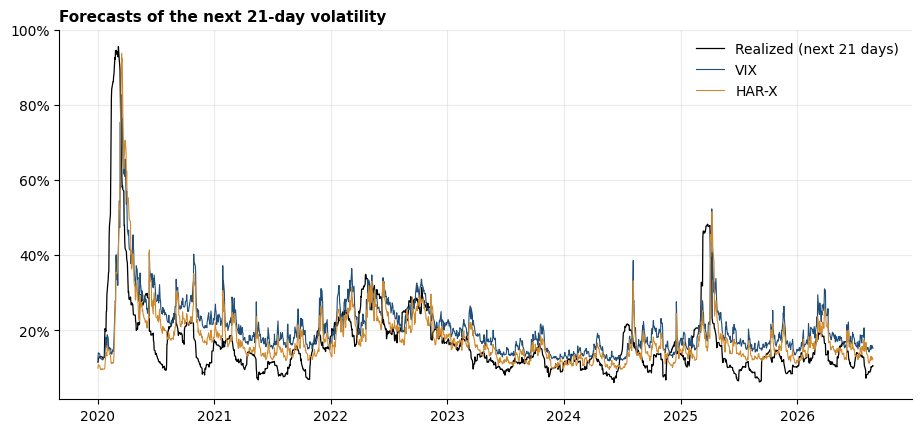

In [3]:
from vrp.plots import PALETTE, style

realized = realized_vol.loc[EVAL_START:].dropna()
fig, ax = plt.subplots(figsize=(11, 4.8))
ax.plot(realized.index, realized, color="black", lw=0.9, label="Realized (next 21 days)")
ax.plot(realized.index, np.sqrt(forecasts["Implied (VIX^2)"]).reindex(realized.index), color=PALETTE[0], lw=0.8, label="VIX")
ax.plot(realized.index, np.sqrt(har_x).reindex(realized.index), color=PALETTE[4], lw=0.8, label="HAR-X")
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
ax.legend(frameon=False)
style(ax, "Forecasts of the next 21-day volatility")
plt.close(fig)
fig

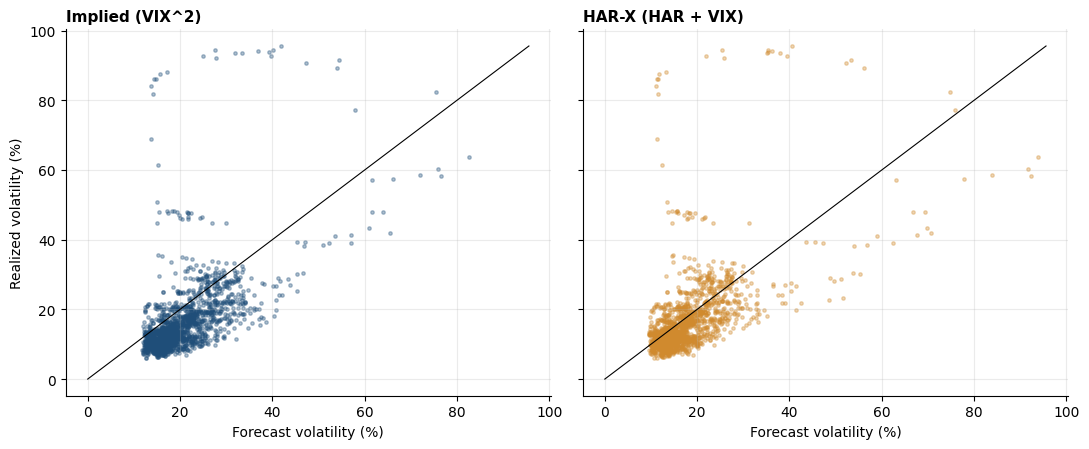

In [4]:
aligned = pd.concat({**window, "realized": realized_var.loc[EVAL_START:]}, axis=1).dropna()
y = aligned.pop("realized")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), sharex=True, sharey=True)
for ax, name, color in zip(axes, ["Implied (VIX^2)", "HAR-X (HAR + VIX)"], [PALETTE[0], PALETTE[4]]):
    x = 100 * np.sqrt(aligned[name])
    z = 100 * np.sqrt(y)
    ax.scatter(x, z, s=6, alpha=0.35, color=color)
    top = max(x.max(), z.max())
    ax.plot([0, top], [0, top], color="black", lw=0.8)
    ax.set_xlabel("Forecast volatility (%)")
    style(ax, name)
axes[0].set_ylabel("Realized volatility (%)")
plt.tight_layout()
plt.close(fig)
fig

Points on the black line would be perfect forecasts. Most points sit below it: both forecasts are higher than what happened, and the VIX more so, which is the premium again. The points high above the line, with realized volatility of 45% to 95% against a forecast of 12% to 30%, are the weeks of February and March 2020 that no model saw coming.

## Is the ranking stable across years?

In [5]:
def qlike(y, f):
    ratio = y / f
    return ratio - np.log(ratio) - 1

losses = pd.DataFrame({name: qlike(y, aligned[name]) for name in aligned})
by_year = losses.groupby(losses.index.year).mean()
by_year["best model"] = by_year.idxmin(axis=1)
by_year.index.name = "year"
by_year.round(3)

,Implied (VIX^2),HAR,HAR-X (HAR + VIX),"GARCH(1,1)-t",best model
year,,,,,
2020,1.450,1.718,1.999,1.941,Implied (VIX^2)
2021,0.366,0.199,0.206,0.216,HAR
2022,0.095,0.166,0.139,0.142,Implied (VIX^2)
2023,0.170,0.138,0.071,0.094,HAR-X (HAR + VIX)
2024,0.221,0.200,0.185,0.229,HAR-X (HAR + VIX)
2025,0.489,0.488,0.482,0.484,HAR-X (HAR + VIX)
2026,0.234,0.151,0.119,0.165,HAR-X (HAR + VIX)


The full-sample ranking hides a split. The VIX has the lowest QLIKE in 2020 and 2022, the two years dominated by a shock or a bear market. In the calmer years, 2023 to 2026, HAR-X is the best model, and HAR wins 2021. The full-window ranking goes to the VIX because losses in 2020 are five to ten times larger than in any other year, so that single year weighs most in the average. In short: the models are slightly better when the regime is stable, and the VIX handles regime changes better.

## What HAR-X learned

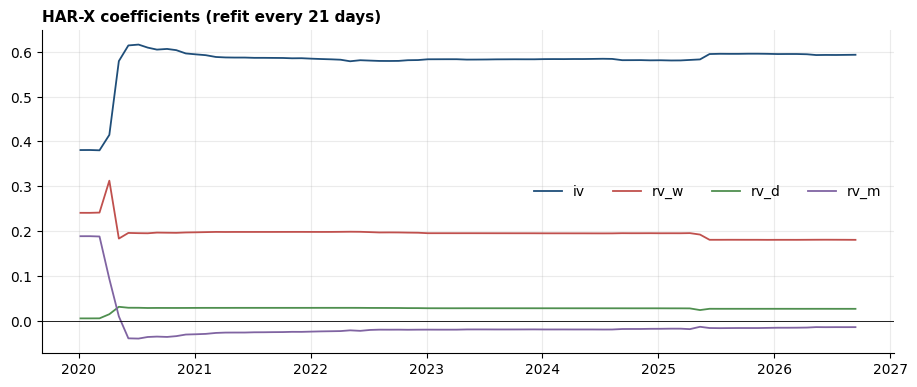

In [6]:
coefs = har_x_coefs.loc[EVAL_START:]
fig, ax = plt.subplots(figsize=(11, 4.2))
for column, color in zip(["iv", "rv_w", "rv_d", "rv_m"], PALETTE):
    ax.plot(coefs.index, coefs[column], color=color, lw=1.3, label=column)
ax.axhline(0, color="black", lw=0.6)
ax.legend(frameon=False, ncol=4)
style(ax, "HAR-X coefficients (refit every 21 days)")
plt.close(fig)
fig

The VIX² coefficient (`iv`) carries most of the weight. It jumps from about 0.4 to 0.6 in spring 2020, when the crisis enters the training sample and the regression learns that the VIX is more informative than recent realized variance, then stays flat. The weekly term settles around 0.2, and the daily and monthly terms stay close to zero. This is why HAR-X ends up close to the VIX: the regression mostly rediscovers it and shrinks it slightly toward recent realized variance.

In [7]:
best_qlike = evaluation["qlike"].idxmin()
best_rmse = evaluation["rmse_vol_pts"].idxmin()
years_model_wins = int((by_year["best model"] != "Implied (VIX^2)").sum())
display(Markdown(
    f"**Summary.** Over the full window the lowest QLIKE belongs to **{best_qlike}** ({evaluation.loc[best_qlike, 'qlike']:.3f}) and the lowest RMSE "
    f"to **{best_rmse}** ({evaluation.loc[best_rmse, 'rmse_vol_pts']:.1f} vol points against {evaluation.loc['Implied (VIX^2)', 'rmse_vol_pts']:.1f} for the VIX). "
    f"A model beats the VIX in {years_model_wins} of {len(by_year)} calendar years, but not in the crisis years, and GARCH(1,1)-t is behind the VIX "
    f"on every loss function. The gap from notebook 01 cannot be forecast with enough reliability to trade on it."
))

**Summary.** Over the full window the lowest QLIKE belongs to **Implied (VIX^2)** (0.444) and the lowest RMSE to **HAR-X (HAR + VIX)** (9.6 vol points against 10.2 for the VIX). A model beats the VIX in 5 of 7 calendar years, but not in the crisis years, and GARCH(1,1)-t is behind the VIX on every loss function. The gap from notebook 01 cannot be forecast with enough reliability to trade on it.